# Diffusion_Experiment2_Hybrid

AWS SageMaker version of `Diffusion_Hebbian_BackProp.ipynb`, isolating **Backprop + Hebbian**.

Companion notebooks in this series:
* `Diffusion_Experiment1_Backprop.ipynb`
* `Diffusion_Experiment2_Hybrid.ipynb`
* `Diffusion_Experiment3_Hebbian.ipynb`

# 1. Imports

This notebook is designed to run on an **AWS SageMaker Studio / Notebook Instance** GPU kernel (e.g. `conda_pytorch_p310` on an `ml.g4dn.xlarge` instance).

In addition to the original PyTorch / DeepInverse imports, we add `boto3` so trained models, loss curves, and generated samples can be pushed to Amazon S3 at the end of the run.

In [1]:
# SageMaker kernels already ship with PyTorch, but deepinv is not preinstalled.
!pip install -q deepinv boto3

import os
import io
import json
import time

import boto3
import numpy as np
import matplotlib.pyplot as plt

import torch
import deepinv
from torchvision import datasets, transforms
import torch.nn.functional as F


# 2. Configuration

Same hyperparameters as the original Colab notebook, plus AWS-specific configuration:

* `S3_BUCKET` / `S3_PREFIX` — where results are uploaded. Leave `S3_BUCKET = None` to skip the upload and keep everything local (e.g. on SageMaker Studio Lab, which has no attached IAM role).
* `LOCAL_OUTPUT_DIR` — local SageMaker Studio storage where models, plots, and logs are written before (optionally) being pushed to S3.

The notebook auto-detects whether it is running with a GPU attached; on SageMaker choose a GPU instance type (e.g. `ml.g4dn.xlarge`) to actually use CUDA.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# -----------------------------
# Training hyperparameters
# -----------------------------
batch_size = 32
image_size = 32
lr = 1e-4
epochs = 20
hebbian_lr = 1e-4
num_images = 1000  # small subset for fast experimentation
seed = 42

torch.manual_seed(seed)

# -----------------------------
# AWS configuration
# -----------------------------
# Set S3_BUCKET to an existing bucket you have write access to, or leave as None
# to keep all outputs local only (nothing will be uploaded).
S3_BUCKET = None            # e.g. "my-diffusion-hebbian-experiments"
S3_PREFIX = "diffusion-hebbian/Diffusion_Experiment2_Hybrid"

LOCAL_OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "Diffusion_Experiment2_Hybrid")
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

EXPERIMENT_NAME = "Diffusion_Experiment2_Hybrid"

print(f"Experiment: {{EXPERIMENT_NAME}}")
print(f"Local output dir: {{LOCAL_OUTPUT_DIR}}")
print(f"S3 target: {{'s3://' + S3_BUCKET + '/' + S3_PREFIX if S3_BUCKET else 'disabled (S3_BUCKET is None)'}}")


Using device: cuda
Experiment: {EXPERIMENT_NAME}
Local output dir: {LOCAL_OUTPUT_DIR}
S3 target: {'s3://' + S3_BUCKET + '/' + S3_PREFIX if S3_BUCKET else 'disabled (S3_BUCKET is None)'}


# 3. MNIST Dataset

Downloads MNIST to local Studio storage (`./data`) and takes a small subset (`num_images`) so each experiment trains quickly enough to compare side by side.

In [3]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.0,), (1.0,))
])

full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

indices = torch.arange(num_images)

train_dataset = torch.utils.data.Subset(
    full_dataset,
    indices
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print(f"Training images: {len(train_dataset)}")


Training images: 1000


# 4. Diffusion Schedule

Standard linear-beta DDPM noise schedule. `alphas_cumprod` is also kept around so we can run a full reverse sampling loop later in **Generate Samples**.

In [4]:
beta_start = 1e-4
beta_end = 0.02
timesteps = 1000

betas = torch.linspace(beta_start, beta_end, timesteps, device=device)

alphas = 1.0 - betas

alphas_cumprod = torch.cumprod(alphas, dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)


# 5. DiffUNet

The same `deepinv.models.DiffUNet` architecture as the original notebook.

In [5]:
model = deepinv.models.DiffUNet(
    in_channels=1,
    out_channels=1,
    pretrained=None
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

mse = torch.nn.MSELoss()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 93,555,841
Trainable parameters: 93,555,841


# 6. Inspect U-Net Layers

Lists every convolutional layer in the network, then picks the layer the Hebbian rule will update.

> **Fix vs. the original Colab notebook:** the original code referenced a variable `hebbian_layer` that was never assigned (it likely relied on manual selection from the printed list that got lost when exporting). Here we select it programmatically — the **last Conv2d layer**, i.e. the layer that directly produces the noise prediction — which matches the notebook's own description of Experiment 3 ("only the final layer is learning").

In [6]:
conv_layers = [
    (name, module)
    for name, module in model.named_modules()
    if isinstance(module, torch.nn.Conv2d)
]

print(f"Found {len(conv_layers)} convolutional layers:")
for name, module in conv_layers:
    print(f"  {name}: {module}")

hebbian_layer_name, hebbian_layer = conv_layers[-1]
print(f"\nHebbian layer selected: '{hebbian_layer_name}'")
print(hebbian_layer)


Found 76 convolutional layers:
  input_blocks.0.0: Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.1.0.in_layers.2: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.1.0.out_layers.3: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.2.0.in_layers.2: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.2.0.out_layers.3: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.3.0.in_layers.2: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.3.0.out_layers.3: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.4.0.in_layers.2: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.4.0.out_layers.3: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  input_blocks.5.0.in_layers.2: Conv2d(128, 256, kernel_size=(3, 3), stride=(1,

# 7. Capture Activations

A forward hook records the input entering `hebbian_layer` on every forward pass. We store it in a small mutable dict (`hebbian_state`) rather than a bare global, so the training functions in **Section 9** can read it cleanly. The hook fires during both normal (`grad`) and `torch.no_grad()` forward passes, so it works for all three experiments.

In [7]:
hebbian_state = {"input": None}


def save_hebbian_input(module, inputs, output):
    hebbian_state["input"] = inputs[0].detach()


hebbian_hook = hebbian_layer.register_forward_hook(save_hebbian_input)


# 8. Hebbian Learning Rule

Same local, biologically-inspired update rule as the original notebook: `ΔW = η · pre-synaptic activity · error`, computed per output/input-channel pair via `unfold` + `einsum`, then normalized before being applied.

In [8]:
def hebbian_conv_update(
    layer,
    layer_input,
    local_error,
    learning_rate
):

    # Extract input patches corresponding to each convolution
    patches = F.unfold(
        layer_input,
        kernel_size=layer.kernel_size,
        dilation=layer.dilation,
        padding=layer.padding,
        stride=layer.stride
    )

    # [B, Cin*K*K, L]

    error = local_error.flatten(2)

    # Make sure the number of spatial locations agrees
    if patches.shape[-1] != error.shape[-1]:
        raise ValueError(
            f"Spatial mismatch: "
            f"patches={patches.shape}, "
            f"error={error.shape}"
        )

    # Hebbian update:
    #
    # ΔW = η * pre-synaptic activity * error
    #
    update = torch.einsum(
        "bol,bil->oi",
        error,
        patches
    )

    # Average across batch and spatial positions
    update /= (
        layer_input.size(0) *
        patches.size(2)
    )

    update = update.view_as(layer.weight)

    # Normalize update
    update = update / (
        update.norm() + 1e-8
    )

    with torch.no_grad():
        layer.weight.add_(
            learning_rate * update
        )


# 9. Training Functions

All three training strategies are defined here so every notebook in the series is self-contained and directly comparable — only the strategy actually invoked in **Section 10** differs between notebooks.

* `train_backprop()` — standard DDPM training (`loss.backward()` + `optimizer.step()`), no Hebbian update.
* `train_hybrid()` — backprop step followed by a Hebbian update on `hebbian_layer`.
* `train_hebbian()` — forward pass only under `torch.no_grad()` (no autograd graph, no optimizer),   the final conv layer is updated purely via `hebbian_conv_update`. The loss is still computed and   logged for comparison, but it never drives a gradient step.

In [9]:
def _forward_diffusion(imgs):
    noise = torch.randn_like(imgs)
    t = torch.randint(0, timesteps, (imgs.size(0),), device=device)
    noised_imgs = (
        sqrt_alphas_cumprod[t, None, None, None] * imgs
        + sqrt_one_minus_alphas_cumprod[t, None, None, None] * noise
    )
    return noised_imgs, noise, t


def train_backprop(model, optimizer, mse, train_loader, epochs):
    """Experiment 1: standard backpropagation baseline."""
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for data, _ in train_loader:
            imgs = data.to(device)
            noised_imgs, noise, t = _forward_diffusion(imgs)

            optimizer.zero_grad()
            estimated_noise = model(noised_imgs, t, type_t="timestep")
            loss = mse(estimated_noise, noise)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"[Backprop] Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.5f}")

    return loss_history


def train_hybrid(model, optimizer, mse, train_loader, epochs, hebbian_layer, hebbian_state, hebbian_lr):
    """Experiment 2: backprop + Hebbian update on the final conv layer."""
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for data, _ in train_loader:
            imgs = data.to(device)
            noised_imgs, noise, t = _forward_diffusion(imgs)

            optimizer.zero_grad()
            estimated_noise = model(noised_imgs, t, type_t="timestep")
            loss = mse(estimated_noise, noise)
            loss.backward()
            optimizer.step()

            local_error = noise - estimated_noise.detach()
            hebbian_conv_update(
                layer=hebbian_layer,
                layer_input=hebbian_state["input"],
                local_error=local_error,
                learning_rate=hebbian_lr
            )

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"[Backprop+Hebbian] Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.5f}")

    return loss_history


def train_hebbian(model, mse, train_loader, epochs, hebbian_layer, hebbian_state, hebbian_lr):
    """Experiment 3: Hebbian-only update on the final conv layer, no backprop/optimizer."""
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for data, _ in train_loader:
            imgs = data.to(device)
            noised_imgs, noise, t = _forward_diffusion(imgs)

            with torch.no_grad():
                estimated_noise = model(noised_imgs, t, type_t="timestep")

            loss = mse(estimated_noise, noise)  # logged only, never backpropped

            local_error = noise - estimated_noise
            hebbian_conv_update(
                layer=hebbian_layer,
                layer_input=hebbian_state["input"],
                local_error=local_error,
                learning_rate=hebbian_lr
            )

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"[Hebbian-only] Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.5f}")

    return loss_history


# 10. Experiment 2 — Backprop + Hebbian

```
                 +-- Backprop --> Adam --+
                 |                       |
Input -> DiffUNet -> Noise prediction    |
                 |                       |
                 +-- Hebbian ------------+---> weights
```

Every step still runs `loss.backward()` / `optimizer.step()`, and in addition the final conv layer (`hebbian_layer`) receives a local Hebbian update via `hebbian_conv_update(...)`. This tells us whether the two learning signals complement or interfere with each other — compare its loss curve against `Diffusion_Experiment1_Backprop.ipynb`.

In [10]:
loss_history = train_hybrid(
    model=model,
    optimizer=optimizer,
    mse=mse,
    train_loader=train_loader,
    epochs=epochs,
    hebbian_layer=hebbian_layer,
    hebbian_state=hebbian_state,
    hebbian_lr=hebbian_lr
)


[Backprop+Hebbian] Epoch [1/20] Loss: 0.53511
[Backprop+Hebbian] Epoch [2/20] Loss: 0.06593
[Backprop+Hebbian] Epoch [3/20] Loss: 0.02335
[Backprop+Hebbian] Epoch [4/20] Loss: 0.02277
[Backprop+Hebbian] Epoch [5/20] Loss: 0.02133
[Backprop+Hebbian] Epoch [6/20] Loss: 0.01779
[Backprop+Hebbian] Epoch [7/20] Loss: 0.01837
[Backprop+Hebbian] Epoch [8/20] Loss: 0.01494
[Backprop+Hebbian] Epoch [9/20] Loss: 0.01690
[Backprop+Hebbian] Epoch [10/20] Loss: 0.01568
[Backprop+Hebbian] Epoch [11/20] Loss: 0.01473
[Backprop+Hebbian] Epoch [12/20] Loss: 0.01574
[Backprop+Hebbian] Epoch [13/20] Loss: 0.01583
[Backprop+Hebbian] Epoch [14/20] Loss: 0.01870
[Backprop+Hebbian] Epoch [15/20] Loss: 0.01448
[Backprop+Hebbian] Epoch [16/20] Loss: 0.01532
[Backprop+Hebbian] Epoch [17/20] Loss: 0.01520
[Backprop+Hebbian] Epoch [18/20] Loss: 0.01716
[Backprop+Hebbian] Epoch [19/20] Loss: 0.01545
[Backprop+Hebbian] Epoch [20/20] Loss: 0.01624


# 11. Loss Curve

Plots this experiment's training loss and saves it alongside the raw numbers, so it can be overlaid with the other two experiments later (e.g. by loading each notebook's `loss_history.json` from S3 into a separate comparison notebook).

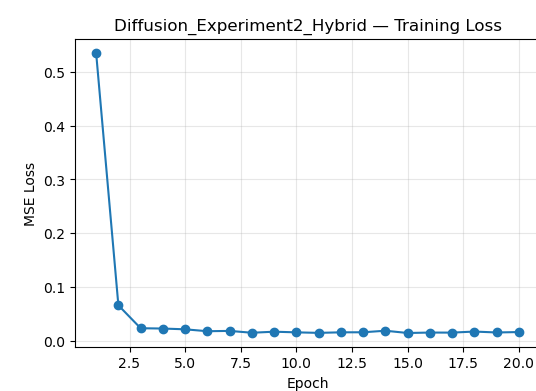

Saved loss curve to /mnt/custom-file-systems/s3/shared/outputs/Diffusion_Experiment2_Hybrid/loss_curve.png
Saved loss history to /mnt/custom-file-systems/s3/shared/outputs/Diffusion_Experiment2_Hybrid/loss_history.json


In [11]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"{EXPERIMENT_NAME} — Training Loss")
plt.grid(alpha=0.3)

loss_plot_path = os.path.join(LOCAL_OUTPUT_DIR, "loss_curve.png")
plt.savefig(loss_plot_path, bbox_inches="tight", dpi=150)
plt.show()

loss_json_path = os.path.join(LOCAL_OUTPUT_DIR, "loss_history.json")
with open(loss_json_path, "w") as f:
    json.dump(loss_history, f)

print(f"Saved loss curve to {loss_plot_path}")
print(f"Saved loss history to {loss_json_path}")


# 12. Generate Samples

The original notebook never implemented reverse sampling, so this adds a standard DDPM ancestral sampler (Ho et al., 2020) built from the schedule in **Section 4**: starting from pure Gaussian noise, it iteratively denoises using the trained model's noise prediction at every timestep.

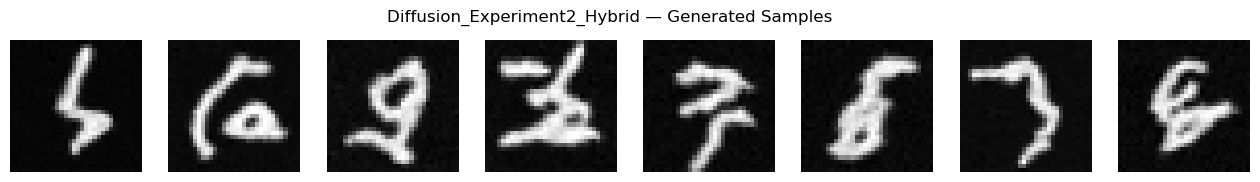

Saved generated samples to /mnt/custom-file-systems/s3/shared/outputs/Diffusion_Experiment2_Hybrid/generated_samples.png


In [12]:
@torch.no_grad()
def generate_samples(model, n_samples, image_size, timesteps, betas, alphas, alphas_cumprod, device):
    model.eval()
    x = torch.randn(n_samples, 1, image_size, image_size, device=device)

    for t in reversed(range(timesteps)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        predicted_noise = model(x, t_batch, type_t="timestep")

        alpha = alphas[t]
        alpha_cumprod = alphas_cumprod[t]
        beta = betas[t]

        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * predicted_noise
        ) + torch.sqrt(beta) * noise

    return x.clamp(-1, 1)


n_samples = 8
samples = generate_samples(
    model, n_samples, image_size, timesteps, betas, alphas, alphas_cumprod, device
)

fig, axes = plt.subplots(1, n_samples, figsize=(2 * n_samples, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i, 0].cpu().numpy(), cmap="gray")
    ax.axis("off")
plt.suptitle(f"{EXPERIMENT_NAME} — Generated Samples")

samples_plot_path = os.path.join(LOCAL_OUTPUT_DIR, "generated_samples.png")
plt.savefig(samples_plot_path, bbox_inches="tight", dpi=150)
plt.show()

print(f"Saved generated samples to {samples_plot_path}")


# 13. Save Models

Saves `state_dict()` locally (standard PyTorch practice) and, if `S3_BUCKET` was set in **Section 2**, uploads the checkpoint, loss history, and plots to `s3://<S3_BUCKET>/<S3_PREFIX>/`. On a SageMaker Studio / Notebook Instance the attached execution role's permissions are used automatically — no credentials need to be hardcoded.

In [13]:
model_path = os.path.join(LOCAL_OUTPUT_DIR, "trained_diffusion_model.pth")
torch.save(model.state_dict(), model_path)
print(f"Saved model locally to {model_path}")

if S3_BUCKET:
    s3 = boto3.client("s3")
    prefix = S3_PREFIX.rstrip("/")

    files_to_upload = [
        model_path,
        loss_plot_path,
        loss_json_path,
        samples_plot_path,
    ]

    for local_path in files_to_upload:
        key = f"{prefix}/{os.path.basename(local_path)}"
        s3.upload_file(local_path, S3_BUCKET, key)
        print(f"Uploaded s3://{S3_BUCKET}/{key}")
else:
    print("S3_BUCKET is None — skipping upload, all outputs remain local only.")


Saved model locally to /mnt/custom-file-systems/s3/shared/outputs/Diffusion_Experiment2_Hybrid/trained_diffusion_model.pth
S3_BUCKET is None — skipping upload, all outputs remain local only.
